# Assignment 2: Classify MNIST + Regularization

Freta Yordinia Laura   
24/533444/PA/22576  

## Load Data

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential, load_model
from keras.layers import Flatten, Dense

keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1, 28,28,1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000, 10)
(10000, 28, 28, 1) (10000, 10)


## Define and Compile Model

In [20]:
keras.utils.set_random_seed(42)
model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

## Fit Model

In [21]:
history1 = model1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model1.save('my_model1.h5')
model1.evaluate(X_test, y_test)
model1.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9443 - loss: 0.1942 - val_acc: 0.9542 - val_loss: 0.1596
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9584 - loss: 0.1426 - val_acc: 0.9639 - val_loss: 0.1289
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9672 - loss: 0.1136 - val_acc: 0.9668 - val_loss: 0.1126
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9731 - loss: 0.0947 - val_acc: 0.9699 - val_loss: 0.1027
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9773 - loss: 0.0809 - val_acc: 0.9710 - val_loss: 0.0967
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9805 - loss: 0.0706 - val_acc: 0.9718 - val_loss: 0.0925
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9828 - loss: 0.0623 - val_acc: 0.9723 - val_loss: 0.0903
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9725 - loss: 0.0881


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

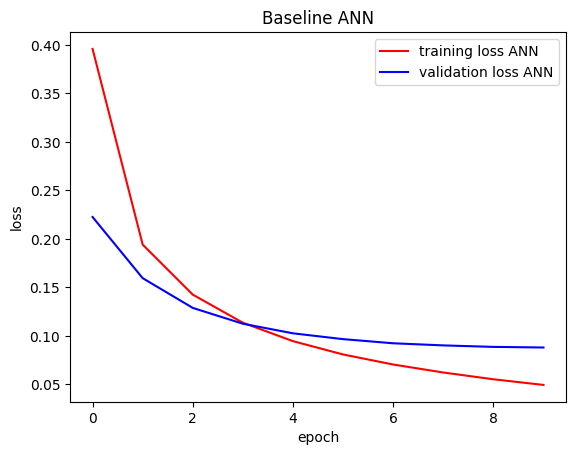

In [22]:
epochs = range(10)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']
plt.plot(epochs, loss1, 'r', label='training loss ANN')
plt.plot(epochs, val_loss1, 'b', label='validation loss ANN')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Baseline ANN')
plt.legend(); plt.show()

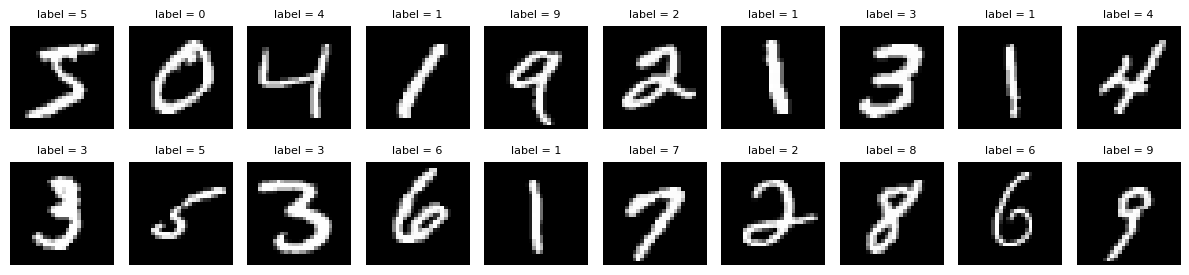

In [23]:
# Tampilkan beberapa contoh citra
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'label = {np.argmax(y_train[i])}', fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

## Load Model dan Prediction

In [24]:
model_simpan = load_model('my_model1.h5')
pred = model_simpan.predict(X_test)
print('label actual:', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 3
label prediction: 3


# Eksperimen

## L1 Regularization (Rate = 0.0001)

In [25]:
from keras import regularizers
keras.utils.set_random_seed(42)
model2 = Sequential()
model2.add(Flatten())
model2.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l1(0.0001)))
model2.add(Dense(10,activation='softmax'))

model2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history2 = model2.fit(X_train,y_train,epochs=10,batch_size=100,validation_data=(X_test,y_test))
model2.summary()
model2.evaluate(X_test,y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8906 - loss: 0.5263 - val_acc: 0.9361 - val_loss: 0.3397
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9420 - loss: 0.3146 - val_acc: 0.9498 - val_loss: 0.2739
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9541 - loss: 0.2624 - val_acc: 0.9589 - val_loss: 0.2392
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9610 - loss: 0.2324 - val_acc: 0.9641 - val_loss: 0.2180
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9652 - loss: 0.2130 - val_acc: 0.9662 - val_loss: 0.2045
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9686 - loss: 0.1990 - val_acc: 0.9687 - val_loss: 0.1943
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9710 - loss: 0.1886 - val_acc: 0.9704 - val_loss: 0.1865
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9730 - loss: 0.1803 - val_acc: 0.9710 - val_loss: 0.1809
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9724 - loss: 0.1716


[0.17158983647823334, 0.9724000096321106]

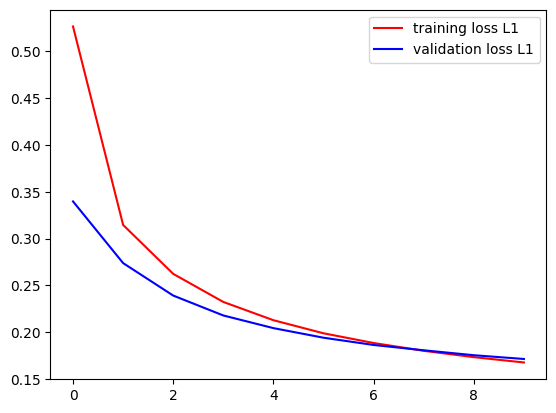

In [26]:
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
plt.plot(range(10),loss2,'r',label='training loss L1')
plt.plot(range(10),val_loss2,'b',label='validation loss L1')
plt.legend()
plt.show()

## L2 Regularization (Rate = 0.001)

In [27]:
keras.utils.set_random_seed(42)
model3 = Sequential()
model3.add(Flatten())
model3.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model3.add(Dense(10,activation='softmax'))

model3.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history3 = model3.fit(X_train,y_train,epochs=10,batch_size=100,validation_data=(X_test,y_test))
model3.summary()
model3.evaluate(X_test,y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8904 - loss: 0.4795 - val_acc: 0.9348 - val_loss: 0.3036
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9420 - loss: 0.2809 - val_acc: 0.9495 - val_loss: 0.2430
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9536 - loss: 0.2348 - val_acc: 0.9586 - val_loss: 0.2140
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9594 - loss: 0.2088 - val_acc: 0.9624 - val_loss: 0.1957
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9639 - loss: 0.1916 - val_acc: 0.9649 - val_loss: 0.1837
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9667 - loss: 0.1795 - val_acc: 0.9666 - val_loss: 0.1750
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9692 - loss: 0.1699 - val_acc: 0.9671 - val_loss: 0.1688
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9711 - loss: 0.1622 - val_acc: 0.9687 - val_loss: 0.1630
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9698 - loss: 0.1541


[0.15413066744804382, 0.9697999954223633]

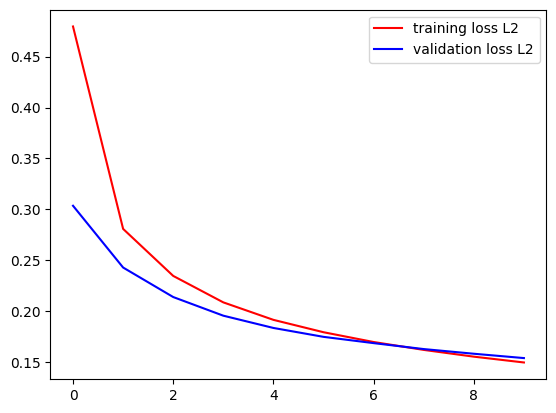

In [28]:
loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']
plt.plot(range(10),loss3,'r',label='training loss L2')
plt.plot(range(10),val_loss3,'b',label='validation loss L2')
plt.legend()
plt.show()

## Dropout (Rate = 0.3)

In [29]:
from keras.layers import Dropout
keras.utils.set_random_seed(42)
model4 = Sequential()
model4.add(Flatten())
model4.add(Dense(64,activation='relu'))
model4.add(Dropout(0.3))
model4.add(Dense(10,activation='softmax'))

model4.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history4 = model4.fit(X_train,y_train,epochs=10,batch_size=100,validation_data=(X_test,y_test))
model4.summary()
model4.evaluate(X_test,y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8504 - loss: 0.5069 - val_acc: 0.9317 - val_loss: 0.2333
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9212 - loss: 0.2701 - val_acc: 0.9499 - val_loss: 0.1735
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9354 - loss: 0.2196 - val_acc: 0.9574 - val_loss: 0.1453
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9432 - loss: 0.1917 - val_acc: 0.9597 - val_loss: 0.1305
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9488 - loss: 0.1727 - val_acc: 0.9633 - val_loss: 0.1216
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9517 - loss: 0.1603 - val_acc: 0.9657 - val_loss: 0.1142
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9552 - loss: 0.1508 - val_acc: 0.9661 - val_loss: 0.1105
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9579 - loss: 0.1407 - val_acc: 0.9691 - val_loss: 0.1021
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9694 - loss: 0.0997


[0.09972984343767166, 0.9693999886512756]

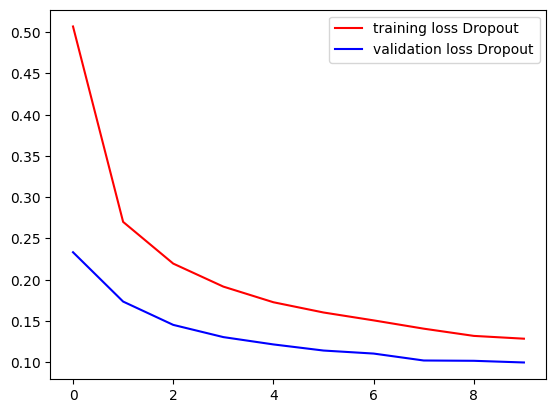

In [30]:
loss4 = history4.history['loss']
val_loss4 = history4.history['val_loss']
plt.plot(range(10),loss4,'r',label='training loss Dropout')
plt.plot(range(10),val_loss4,'b',label='validation loss Dropout')
plt.legend()
plt.show()

## Early Stopping

In [31]:
from keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
keras.utils.set_random_seed(42)
model5 = Sequential()
model5.add(Flatten())
model5.add(Dense(64,activation='relu'))
model5.add(Dense(10,activation='softmax'))

model5.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history5 = model5.fit(X_train,y_train,epochs=50,batch_size=100,validation_data=(X_test,y_test),callbacks=[es])
model5.summary()
model5.evaluate(X_test,y_test)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9443 - loss: 0.1942 - val_acc: 0.9542 - val_loss: 0.1596
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9584 - loss: 0.1426 - val_acc: 0.9639 - val_loss: 0.1289
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9672 - loss: 0.1136 - val_acc: 0.9668 - val_loss: 0.1126
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9731 - loss: 0.0947 - val_acc: 0.9699 - val_loss: 0.1027
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9773 - loss: 0.0809 - val_acc: 0.9710 - val_loss: 0.0967
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9805 - loss: 0.0706 - val_acc: 0.9718 - val_loss: 0.0925
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9828 - loss: 0.0623 - val_acc: 0.9723 - val_loss: 0.0903
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9725 - loss: 0.0877


[0.08770807832479477, 0.9725000262260437]

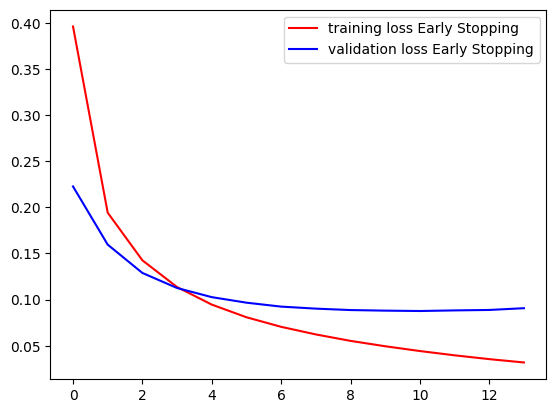

berhenti di epoch 14


In [32]:
loss5 = history5.history['loss']
val_loss5 = history5.history['val_loss']
epochs5 = range(len(loss5))
plt.plot(epochs5,loss5,'r',label='training loss Early Stopping')
plt.plot(epochs5,val_loss5,'b',label='validation loss Early Stopping')
plt.legend()
plt.show()
print('berhenti di epoch', len(loss5))

## L1 Regularization + Dropout

In [33]:
keras.utils.set_random_seed(42)
model6 = Sequential()
model6.add(Flatten())
model6.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l1(0.0001)))
model6.add(Dropout(0.3))
model6.add(Dense(10,activation='softmax'))

model6.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history6 = model6.fit(X_train,y_train,epochs=10,batch_size=100,validation_data=(X_test,y_test))
model6.summary()
model6.evaluate(X_test,y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8497 - loss: 0.6437 - val_acc: 0.9309 - val_loss: 0.3580
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9177 - loss: 0.4023 - val_acc: 0.9476 - val_loss: 0.2946
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9303 - loss: 0.3504 - val_acc: 0.9541 - val_loss: 0.2640
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9370 - loss: 0.3207 - val_acc: 0.9578 - val_loss: 0.2441
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9425 - loss: 0.3036 - val_acc: 0.9622 - val_loss: 0.2295
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9446 - loss: 0.2897 - val_acc: 0.9649 - val_loss: 0.2198
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9466 - loss: 0.2799 - val_acc: 0.9641 - val_loss: 0.2150
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9489 - loss: 0.2704 - val_acc: 0.9660 - val_loss: 0.2115
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9678 - loss: 0.2007


[0.20066000521183014, 0.9678000211715698]

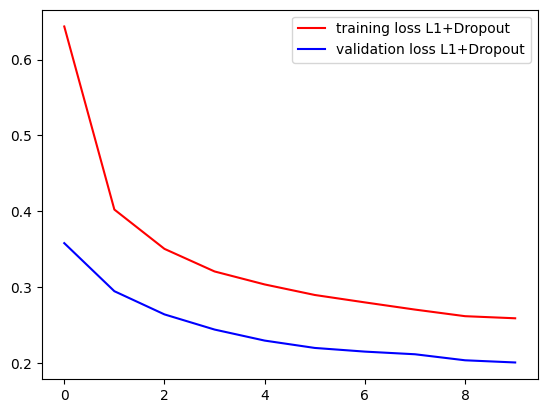

In [34]:
loss6 = history6.history['loss']
val_loss6 = history6.history['val_loss']
plt.plot(range(10),loss6,'r',label='training loss L1+Dropout')
plt.plot(range(10),val_loss6,'b',label='validation loss L1+Dropout')
plt.legend()
plt.show()

# Perbandingan Semua Model

In [35]:
models = [model1, model2, model3, model4, model5, model6]
names = ['Baseline', 'L1', 'L2', 'Dropout', 'Early Stopping', 'L1+Dropout']

for i in range(6):
    loss, acc = models[i].evaluate(X_test, y_test, verbose=0)
    print(names[i], '-> acc:', round(acc,4), ' loss:', round(loss,4))

Baseline -> acc: 0.9725  loss: 0.0881
L1 -> acc: 0.9724  loss: 0.1716
L2 -> acc: 0.9698  loss: 0.1541
Dropout -> acc: 0.9694  loss: 0.0997
Early Stopping -> acc: 0.9725  loss: 0.0877
L1+Dropout -> acc: 0.9678  loss: 0.2007


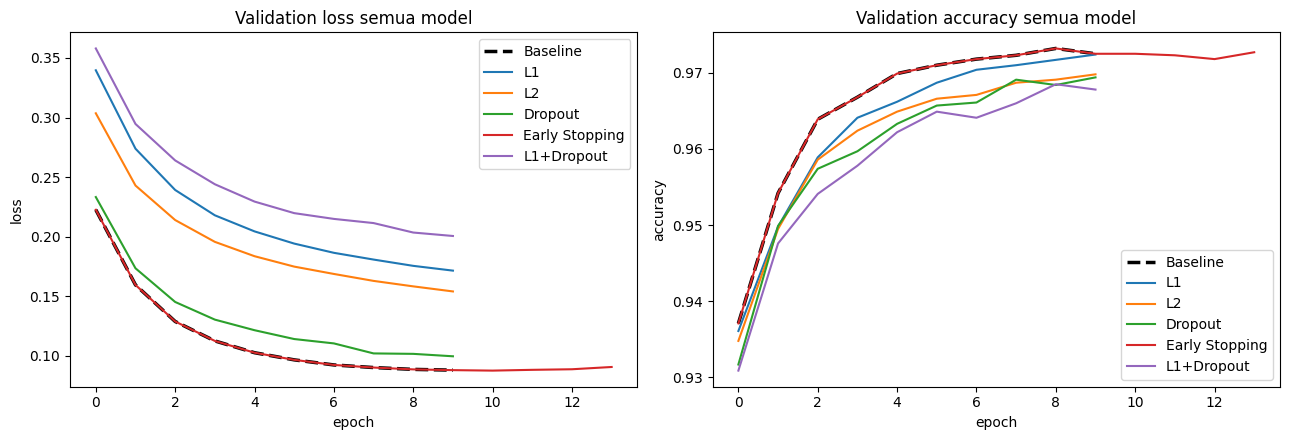

In [36]:
histories = [history1, history2, history3, history4, history5, history6]
plt.figure(figsize=(13,4.5))

plt.subplot(1,2,1)
for i in range(6):
    if names[i] == 'Baseline':
        plt.plot(histories[i].history['val_loss'], 'k--', linewidth=2.5, label=names[i])
    else:
        plt.plot(histories[i].history['val_loss'], label=names[i])
plt.title('Validation loss semua model')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1,2,2)
for i in range(6):
    if names[i] == 'Baseline':
        plt.plot(histories[i].history['val_acc'], 'k--', linewidth=2.5, label=names[i])
    else:
        plt.plot(histories[i].history['val_acc'], label=names[i])
plt.title('Validation accuracy semua model')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.show()